# SWaT ICS Intrusion Detection — Full ML Pipeline
## Secure Water Treatment (SWaT) Anomaly & Multi-Class Attack Detection

**Dataset:** 4-run merged dataset · 117,695 rows · 75 columns · 9 attack classes  
**Models:** Random Forest · XGBoost · SVM · MLP · LSTM (sequence)  
**Output:** Trained models saved as `.joblib` for deployment

---
### Pipeline Stages
| # | Stage | Description |
|---|-------|-------------|
| 1 | Data Loading | Load compressed CSV, validate schema |
| 2 | Preprocessing | Remap IDs, drop dead columns, fix boundary leakage |
| 3 | Feature Engineering | Temporal rolling features, derivatives, CUSUM |
| 4 | Class Balancing | SMOTE + class weight computation |
| 5 | Classical ML | Random Forest, XGBoost, SVM (binary + multi-class) |
| 6 | Neural Networks | MLP (tabular) + LSTM (sequential) |
| 7 | Evaluation | Confusion matrices, ROC curves, per-attack metrics |
| 8 | Model Saving | Export all models as `.joblib` |


## 0. Imports & Setup

In [20]:
# Install required packages (run once)
# !pip install scikit-learn xgboost imbalanced-learn joblib torch matplotlib seaborn pandas numpy


In [21]:
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [22]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from collections import Counter

# ── Sklearn ───────────────────────────────────────────────────────────────────
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import RobustScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay, f1_score, accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight
import joblib

# ── XGBoost ───────────────────────────────────────────────────────────────────
import xgboost as xgb

# ── Imbalanced-learn ──────────────────────────────────────────────────────────
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', '{:.4f}'.format)
np.random.seed(42)
torch.manual_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}  |  XGBoost: {xgb.__version__}")

# ── Output dir ────────────────────────────────────────────────────────────────
MODELS_DIR = Path("saved_models")
MODELS_DIR.mkdir(exist_ok=True)
PLOTS_DIR  = Path("plots")
PLOTS_DIR.mkdir(exist_ok=True)
print(f"Models will be saved to: {MODELS_DIR.resolve()}")


Device: cpu
PyTorch: 2.10.0+cpu  |  XGBoost: 3.2.0
Models will be saved to: C:\Users\Dweep\Documents\test\saved_models


## 1. Data Loading & Initial Validation

In [23]:
# ── Attack registry ───────────────────────────────────────────────────────────
ATTACK_NAMES = {
    0: "Normal Operation",
    1: "Tank Overflow Attack",
    2: "Chemical Depletion Attack",
    3: "Membrane Damage Attack",
    4: "pH Manipulation Attack",
    5: "Slow Ramp Attack",
    6: "Reconnaissance Scan",
    7: "Denial of Service",
    8: "Replay Attack",
    9: "Valve Manipulation Attack"
}

# Original ATTACK_IDs in the merged CSV → desired sequential IDs
ID_REMAP = {0: 0, 8: 1, 9: 2, 10: 3, 11: 4, 12: 5, 13: 6, 14: 7, 15: 8, 16: 9}

# ── Load ──────────────────────────────────────────────────────────────────────
DATA_PATH = "final.csv"   # <-- change to your path if different

df_raw = pd.read_csv(DATA_PATH)
print(f"Loaded: {df_raw.shape[0]:,} rows  x  {df_raw.shape[1]} columns")
print(f"Missing values: {df_raw.isnull().sum().sum()}")
print(f"Duplicate rows: {df_raw.duplicated().sum()}")
print(f"\nOriginal ATTACK_IDs: {sorted(df_raw['ATTACK_ID'].unique())}")


Loaded: 118,634 rows  x  75 columns
Missing values: 0
Duplicate rows: 0

Original ATTACK_IDs: [np.int64(0), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16)]


In [24]:
# ── Remap ATTACK_IDs to sequential 0–9 ───────────────────────────────────────
df_raw['ATTACK_ID'] = df_raw['ATTACK_ID'].map(ID_REMAP)
df_raw['ATTACK_NAME'] = df_raw['ATTACK_ID'].map(ATTACK_NAMES)

print("Attack distribution after remap:")
dist = df_raw.groupby(['ATTACK_ID','ATTACK_NAME']).size().reset_index(name='rows')
dist['pct'] = (dist['rows'] / len(df_raw) * 100).round(2)
print(dist.to_string(index=False))


Attack distribution after remap:
 ATTACK_ID               ATTACK_NAME  rows     pct
         0          Normal Operation 83386 70.2900
         1      Tank Overflow Attack  4790  4.0400
         2 Chemical Depletion Attack  1594  1.3400
         3    Membrane Damage Attack  2475  2.0900
         4    pH Manipulation Attack  3876  3.2700
         5          Slow Ramp Attack  6299  5.3100
         6       Reconnaissance Scan  5196  4.3800
         7         Denial of Service   980  0.8300
         8             Replay Attack  3861  3.2500
         9 Valve Manipulation Attack  6177  5.2100


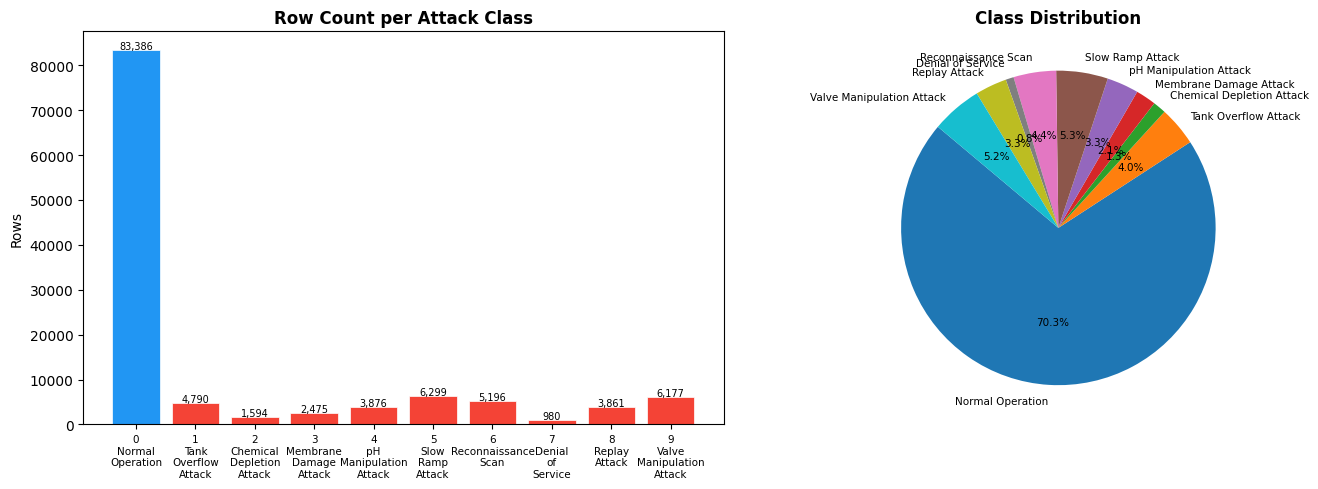

Normal:Attack ratio = 2.37:1


In [25]:
# ── Class balance visualisation ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df_raw.groupby('ATTACK_ID').size()
labels = [f"{i}\n{ATTACK_NAMES[i].replace(' ',chr(10))}" for i in counts.index]
colors = ['#2196F3' if i==0 else '#F44336' for i in counts.index]
axes[0].bar(range(len(counts)), counts.values, color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_xticks(range(len(counts)))
axes[0].set_xticklabels(labels, fontsize=7.5)
axes[0].set_title("Row Count per Attack Class", fontweight='bold')
axes[0].set_ylabel("Rows")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f"{v:,}", ha='center', fontsize=7)

axes[1].pie(counts.values, labels=[ATTACK_NAMES[i] for i in counts.index],
            autopct='%1.1f%%', startangle=140, textprops={'fontsize':7.5})
axes[1].set_title("Class Distribution", fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS_DIR / "class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Normal:Attack ratio = {counts[0]/counts[1:].sum():.2f}:1")


## 2. Preprocessing

### 2.1 Drop Dead & Near-Constant Columns

In [26]:
# Columns confirmed dead across all 4 runs (from validation report)
DEAD_COLS = [
    # Zero-variance / near-constant RO-Stage 5 sensors
    'DPIT_301', 'FIT_301', 'UF_Last_Backwash', 'Turbidity_UF',
    'AIT_501', 'AIT_502', 'AIT_503', 'AIT_504',
    'FIT_501', 'FIT_502', 'FIT_503', 'FIT_504',
    'PIT_501', 'PIT_502', 'PIT_503',
    'RO_Runtime', 'RO_Fouling_Factor', 'RO_Last_Cleaning',
    'TDS_Feed', 'TDS_Permeate', 'FIT_601',
    'Energy_P501', 'Energy_Total',
    # Dead booleans (always same state)
    'P_203', 'MV_303', 'MV_304', 'P_301', 'UF_Backwash_Active',
    'P_403', 'P_501', 'RO_Cleaning_Active', 'P_601', 'P_602', 'P_603',
    'High_Fouling_Alarm',
    # Monotone counters (leak time, not attack info)
    'UF_Runtime', 'Energy_P301', 'RO_Last_Cleaning',
    # Redundant (identical to High_Level_Alarm)
    'System_Run',
    # Near-zero correlation
    'UV_401',
]
# Only drop columns that actually exist in dataframe
DEAD_COLS = [c for c in DEAD_COLS if c in df_raw.columns]

df = df_raw.drop(columns=DEAD_COLS)
print(f"Dropped {len(DEAD_COLS)} dead columns: {len(df_raw.columns)} -> {len(df.columns)} columns")


Dropped 40 dead columns: 75 -> 36 columns


### 2.2 Fix Boundary Label Leakage

In [27]:
def remove_boundary_leakage(df, time_col='elapsed_seconds', label_col='ATTACK_ID',
                             run_col='run_id', window_s=4.0):
    """Drop rows within ±window_s of any attack transition, per run."""
    clean_parts = []
    total_removed = 0
    for rid, grp in df.groupby(run_col):
        grp = grp.sort_values(time_col).reset_index(drop=True)
        transitions = grp[label_col].diff().abs() > 0
        t_times = grp.loc[transitions, time_col].values
        mask = pd.Series(False, index=grp.index)
        for t in t_times:
            mask |= (grp[time_col] - t).abs() <= window_s
        removed = mask.sum()
        total_removed += removed
        clean_parts.append(grp[~mask])
    df_clean = pd.concat(clean_parts, ignore_index=True)
    print(f"Removed {total_removed:,} boundary-leakage rows ({total_removed/len(df)*100:.2f}%)")
    print(f"Remaining: {len(df_clean):,} rows")
    return df_clean

df = remove_boundary_leakage(df, window_s=4.0)


Removed 800 boundary-leakage rows (0.67%)
Remaining: 117,834 rows


### 2.3 Normalise Per-Run Tank Starting Levels

In [28]:
# Acid_Tank_Level has 25-unit cross-run drift in normal baseline
# Normalise chemical tanks relative to each run's initial normal reading
TANK_COLS = ['Acid_Tank_Level', 'Chlorine_Tank_Level',
             'Coagulant_Tank_Level', 'Bisulfate_Tank_Level']

for col in TANK_COLS:
    if col not in df.columns:
        continue
    run_starts = (
        df[df['ATTACK_ID'] == 0]
        .groupby('run_id')[col]
        .first()
        .rename(f'{col}_run_start')
    )
    df = df.join(run_starts, on='run_id')
    df[f'{col}_pct_depleted'] = (
        (df[f'{col}_run_start'] - df[col]) / df[f'{col}_run_start'].clip(lower=1)
    ).clip(0, 1)
    df.drop(columns=[f'{col}_run_start'], inplace=True)

print("Added per-run normalised depletion features:")
pct_cols = [c for c in df.columns if '_pct_depleted' in c]
print(" ", pct_cols)
print(df[pct_cols].describe().round(4))


Added per-run normalised depletion features:
  ['Acid_Tank_Level_pct_depleted', 'Chlorine_Tank_Level_pct_depleted', 'Coagulant_Tank_Level_pct_depleted', 'Bisulfate_Tank_Level_pct_depleted']
       Acid_Tank_Level_pct_depleted  Chlorine_Tank_Level_pct_depleted  \
count                   117834.0000                       117834.0000   
mean                         0.0795                            0.1721   
std                          0.1646                            0.2296   
min                          0.0000                            0.0000   
25%                          0.0000                            0.0000   
50%                          0.0000                            0.0000   
75%                          0.0000                            0.3448   
max                          0.9733                            0.9855   

       Coagulant_Tank_Level_pct_depleted  Bisulfate_Tank_Level_pct_depleted  
count                        117834.0000                        117834.000

### 2.4 Convert Bool Columns to Int

In [29]:
bool_cols = [c for c in df.columns if df[c].dtype == bool]
df[bool_cols] = df[bool_cols].astype(int)
print(f"Converted {len(bool_cols)} bool columns to int: {bool_cols}")


Converted 11 bool columns to int: ['MV_101', 'P_101', 'P_102', 'MV_201', 'P_205', 'P_206', 'MV_301', 'MV_302', 'P_401', 'Chemical_Low_Alarm', 'High_Level_Alarm']


## 3. Feature Engineering — Temporal & Derived Features

In [30]:
WINDOW_SIZES = [10, 25, 50]   # samples = 2s, 5s, 10s at 5Hz

# Key sensors to build temporal features on
TEMPORAL_SENSORS = [
    'LIT_101', 'LIT_301', 'LIT_401',
    'AIT_202', 'FIT_101', 'FIT_401',
    'Acid_Tank_Level', 'Chlorine_Residual',
]
TEMPORAL_SENSORS = [c for c in TEMPORAL_SENSORS if c in df.columns]

def add_temporal_features(df, sensors, windows, run_col='run_id',
                           time_col='elapsed_seconds'):
    """Add rolling mean, std, rate-of-change (1st derivative), and
    CUSUM statistic for each sensor × window combination, per run."""
    parts = []
    for rid, grp in df.groupby(run_col):
        grp = grp.sort_values(time_col).copy()
        dt = grp[time_col].diff().fillna(0.2)   # nominal 0.2s poll
        for s in sensors:
            if s not in grp.columns:
                continue
            # 1st derivative (rate of change per second)
            grp[f'd_{s}_dt'] = grp[s].diff().fillna(0) / dt.clip(lower=0.01)
            for w in windows:
                roll = grp[s].rolling(w, min_periods=max(1, w//2))
                grp[f'{s}_rmean{w}'] = roll.mean()
                grp[f'{s}_rstd{w}']  = roll.std().fillna(0)
            # CUSUM: cumulative sum of deviations from rolling mean
            baseline = grp[s].rolling(50, min_periods=10).mean().fillna(grp[s].mean())
            grp[f'{s}_cusum'] = (grp[s] - baseline).cumsum()
            # Reset CUSUM per run (avoid inter-run leakage)
            grp[f'{s}_cusum'] = grp[f'{s}_cusum'] - grp[f'{s}_cusum'].iloc[0]
        parts.append(grp)
    return pd.concat(parts, ignore_index=True)

print("Adding temporal features (this may take ~30s)...")
df = add_temporal_features(df, TEMPORAL_SENSORS, WINDOW_SIZES)
new_feats = [c for c in df.columns if any(
    x in c for x in ['_rmean','_rstd','d_','_cusum'])]
print(f"Added {len(new_feats)} temporal features. Total columns: {len(df.columns)}")
print("Sample new features:", new_feats[:8])


Adding temporal features (this may take ~30s)...
Added 67 temporal features. Total columns: 104
Sample new features: ['Acid_Tank_Level', 'elapsed_seconds', 'Acid_Tank_Level_pct_depleted', 'd_LIT_101_dt', 'LIT_101_rmean10', 'LIT_101_rstd10', 'LIT_101_rmean25', 'LIT_101_rstd25']


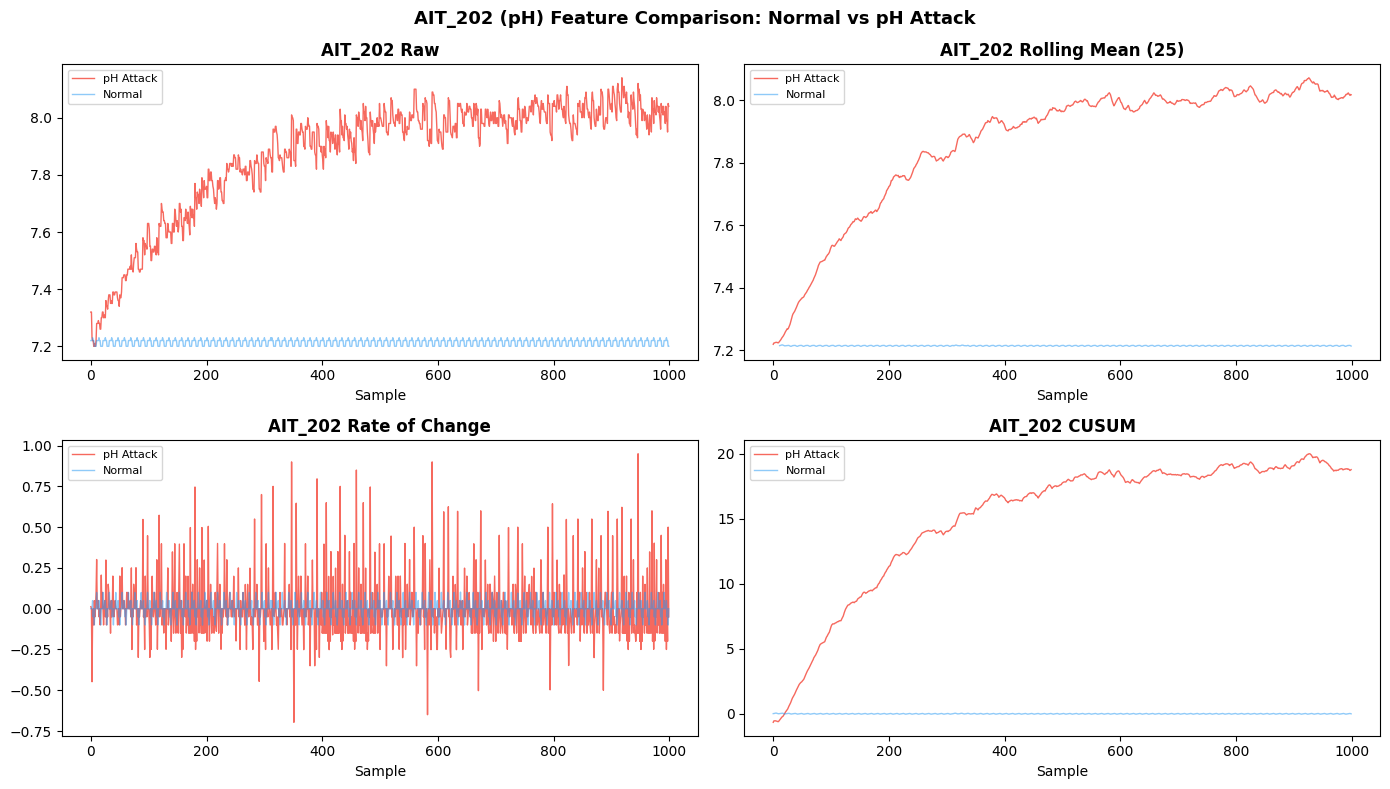

In [31]:
# ── Visualise rolling features for pH attack ──────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

ph_atk = df[df['ATTACK_ID'] == 4].reset_index(drop=True).head(1000)
normal_samp = df[df['ATTACK_ID'] == 0].reset_index(drop=True).head(1000)

for ax, col, title in zip(
    axes.flat,
    ['AIT_202', 'AIT_202_rmean25', 'd_AIT_202_dt', 'AIT_202_cusum'],
    ['AIT_202 Raw', 'AIT_202 Rolling Mean (25)', 'AIT_202 Rate of Change', 'AIT_202 CUSUM']
):
    if col in ph_atk.columns:
        ax.plot(ph_atk[col].values, color='#F44336', alpha=0.8, label='pH Attack', lw=1)
        ax.plot(normal_samp[col].values, color='#2196F3', alpha=0.5, label='Normal', lw=1)
        ax.set_title(title, fontweight='bold')
        ax.legend(fontsize=8)
        ax.set_xlabel("Sample")

plt.suptitle("AIT_202 (pH) Feature Comparison: Normal vs pH Attack",
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "temporal_features_pH.png", dpi=150, bbox_inches='tight')
plt.show()


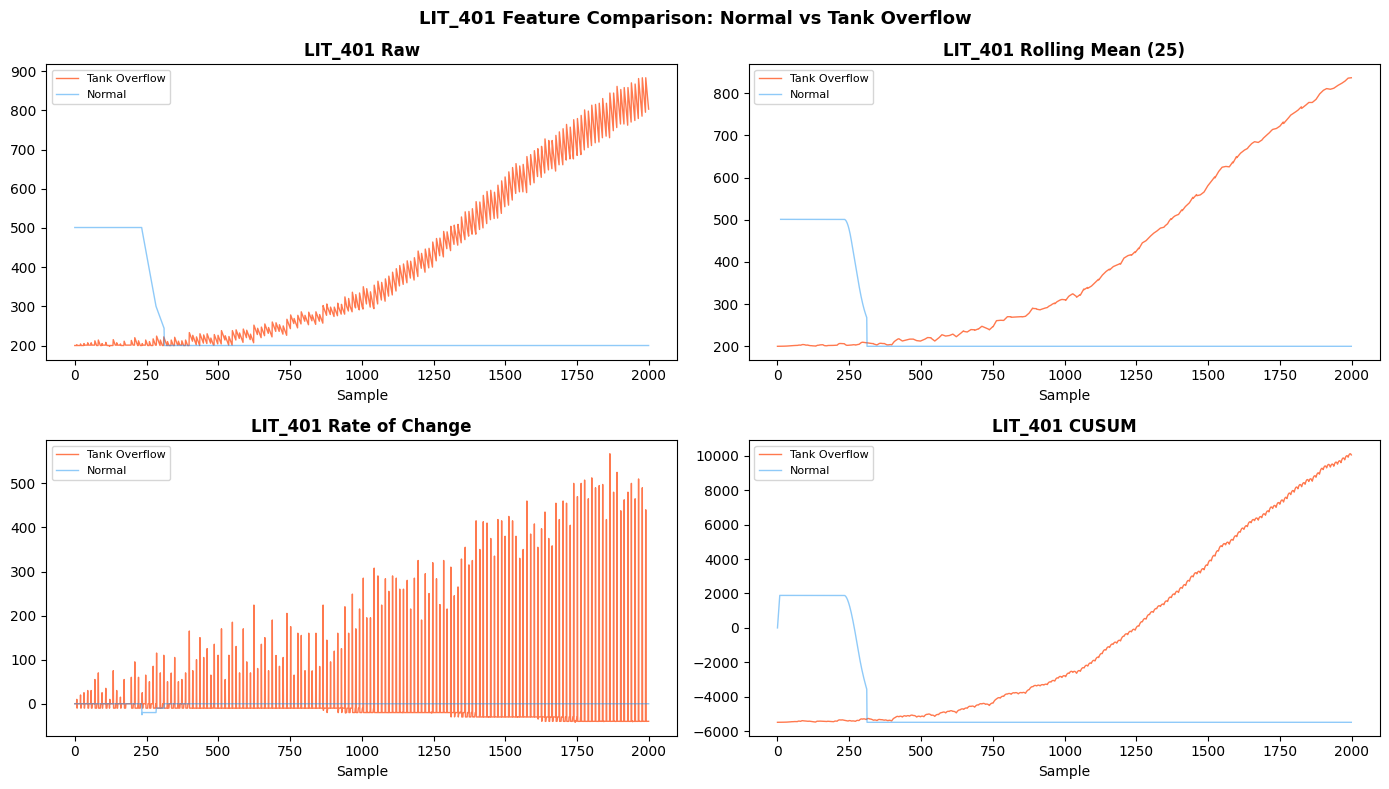

In [32]:
# ── Visualise level features for overflow ─────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

ovfl = df[df['ATTACK_ID'] == 1].reset_index(drop=True).head(2000)
norm = df[df['ATTACK_ID'] == 0].reset_index(drop=True).head(2000)

for ax, col, title in zip(
    axes.flat,
    ['LIT_401', 'LIT_401_rmean25', 'd_LIT_401_dt', 'LIT_401_cusum'],
    ['LIT_401 Raw', 'LIT_401 Rolling Mean (25)', 'LIT_401 Rate of Change', 'LIT_401 CUSUM']
):
    if col in ovfl.columns:
        ax.plot(ovfl[col].values, color='#FF5722', alpha=0.8, label='Tank Overflow', lw=1)
        ax.plot(norm[col].values, color='#2196F3', alpha=0.5, label='Normal', lw=1)
        ax.set_title(title, fontweight='bold')
        ax.legend(fontsize=8)
        ax.set_xlabel("Sample")

plt.suptitle("LIT_401 Feature Comparison: Normal vs Tank Overflow",
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "temporal_features_overflow.png", dpi=150, bbox_inches='tight')
plt.show()


## 4. Feature Matrix & Train/Test Split

In [33]:
# ── Define feature columns ────────────────────────────────────────────────────
DROP_FROM_FEATURES = [
    'Timestamp', 'ATTACK_ID', 'ATTACK_NAME', 'MITRE_ID',
    'run_id', 'elapsed_seconds',
]
DROP_FROM_FEATURES = [c for c in DROP_FROM_FEATURES if c in df.columns]

FEATURE_COLS = [c for c in df.columns if c not in DROP_FROM_FEATURES]
# Drop any remaining string columns
FEATURE_COLS = [c for c in FEATURE_COLS
                if df[c].dtype in [np.float64, np.int64, np.int32, bool, int, float]]

print(f"Feature matrix: {len(FEATURE_COLS)} features")
print(f"Sample features: {FEATURE_COLS[:10]}")

X = df[FEATURE_COLS].values.astype(np.float32)
y = df['ATTACK_ID'].values.astype(np.int64)
y_binary = (y > 0).astype(np.int64)   # 0=Normal, 1=Attack

print(f"\nX shape: {X.shape}   y unique: {np.unique(y)}")
print(f"Binary: Normal={np.sum(y_binary==0):,}  Attack={np.sum(y_binary==1):,}")


Feature matrix: 98 features
Sample features: ['FIT_101', 'LIT_101', 'MV_101', 'P_101', 'P_102', 'AIT_201', 'AIT_202', 'AIT_203', 'Chlorine_Residual', 'FIT_201']

X shape: (117834, 98)   y unique: [0 1 2 3 4 5 6 7 8 9]
Binary: Normal=82,986  Attack=34,848


In [34]:
# ── Stratified train/test split ───────────────────────────────────────────────
X_train, X_test, y_train, y_test, y_bin_train, y_bin_test = train_test_split(
    X, y, y_binary,
    test_size=0.20,
    random_state=42,
    stratify=y        # preserve per-class proportions
)
print(f"Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}")
print("\nTrain class distribution:")
for cls, cnt in sorted(Counter(y_train).items()):
    print(f"  [{cls}] {ATTACK_NAMES[cls]:35s}: {cnt:,}  ({cnt/len(y_train)*100:.1f}%)")


Train: 94,267  |  Test: 23,567

Train class distribution:
  [0] Normal Operation                   : 66,389  (70.4%)
  [1] Tank Overflow Attack               : 3,800  (4.0%)
  [2] Chemical Depletion Attack          : 1,259  (1.3%)
  [3] Membrane Damage Attack             : 1,964  (2.1%)
  [4] pH Manipulation Attack             : 3,069  (3.3%)
  [5] Slow Ramp Attack                   : 4,991  (5.3%)
  [6] Reconnaissance Scan                : 4,093  (4.3%)
  [7] Denial of Service                  : 768  (0.8%)
  [8] Replay Attack                      : 3,041  (3.2%)
  [9] Valve Manipulation Attack          : 4,893  (5.2%)


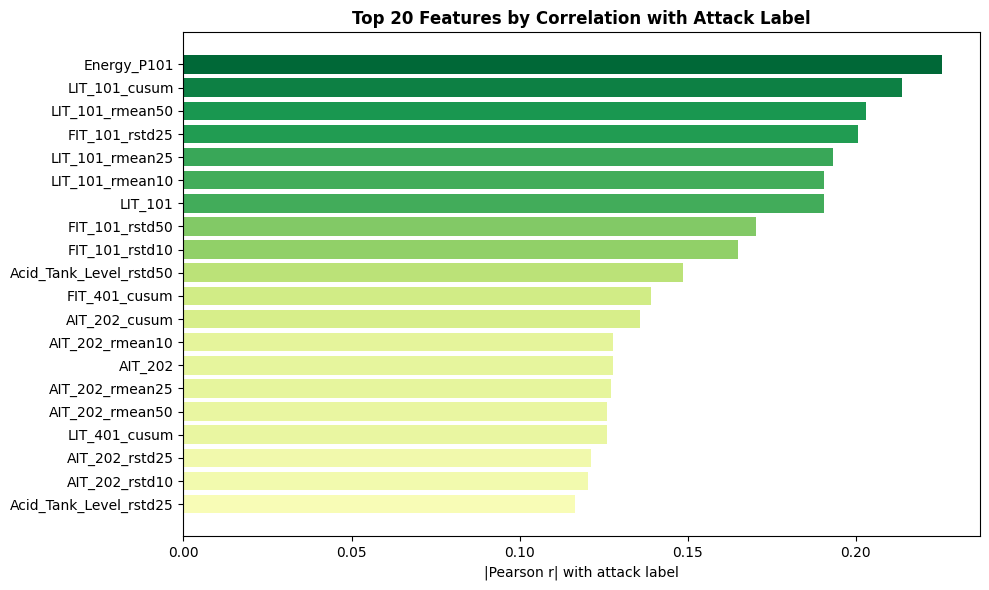

Top 10 features:
  Energy_P101                        : |r| = 0.2256
  LIT_101_cusum                      : |r| = 0.2137
  LIT_101_rmean50                    : |r| = 0.2031
  FIT_101_rstd25                     : |r| = 0.2007
  LIT_101_rmean25                    : |r| = 0.1932
  LIT_101_rmean10                    : |r| = 0.1906
  LIT_101                            : |r| = 0.1905
  FIT_101_rstd50                     : |r| = 0.1703
  FIT_101_rstd10                     : |r| = 0.1649
  Acid_Tank_Level_rstd50             : |r| = 0.1486


In [35]:
# ── Feature correlation heatmap (top 20 features) ────────────────────────────
corr_label = pd.Series(y_train).astype(float)
feat_df = pd.DataFrame(X_train[:, :len(FEATURE_COLS)], columns=FEATURE_COLS)
correlations = feat_df.corrwith(corr_label).abs().sort_values(ascending=False)

top20 = correlations.head(20)
fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.RdYlGn(top20.values / top20.values.max())
ax.barh(top20.index[::-1], top20.values[::-1], color=colors[::-1])
ax.set_xlabel("|Pearson r| with attack label")
ax.set_title("Top 20 Features by Correlation with Attack Label", fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS_DIR / "feature_importance_corr.png", dpi=150, bbox_inches='tight')
plt.show()
print("Top 10 features:")
for feat, corr in top20.head(10).items():
    print(f"  {feat:35s}: |r| = {corr:.4f}")


## 5. Scaling & Class Balancing

### 5.1 RobustScaler (handles attack outliers better than MinMaxScaler)

In [36]:
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaler fitted on training data only (no test leakage)")
print(f"Feature range after scaling — train: [{X_train_scaled.min():.2f}, {X_train_scaled.max():.2f}]")
print(f"Feature range after scaling — test:  [{X_test_scaled.min():.2f}, {X_test_scaled.max():.2f}]")

# Save scaler immediately
joblib.dump(scaler, MODELS_DIR / "scaler.joblib")
print(f"\nScaler saved: {MODELS_DIR}/scaler.joblib")


Scaler fitted on training data only (no test leakage)
Feature range after scaling — train: [nan, nan]
Feature range after scaling — test:  [nan, nan]

Scaler saved: saved_models/scaler.joblib


### 5.2 SMOTE Oversampling (minority classes)

In [37]:
# SMOTE needs at least k_neighbors+1 samples per class
# DoS (class 7) has fewest samples — use k_neighbors=3
from collections import Counter

print("Class distribution BEFORE SMOTE:")
for cls, cnt in sorted(Counter(y_train).items()):
    print(f"  [{cls}] {ATTACK_NAMES[cls]:35s}: {cnt:,}")

smote = SMOTE(
    random_state=42,
    k_neighbors=3,
    sampling_strategy={
        # Only oversample minority classes — don't touch Normal or Valve Manip
        2: 3000,    # Chemical Depletion: 1,275 -> 3,000
        3: 3000,    # Membrane Damage:    1,980 -> 3,000
        7: 3000,    # Denial of Service:    784 -> 3,000
    }
)

X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)
y_bin_train_bal = (y_train_bal > 0).astype(np.int64)

print("\nClass distribution AFTER SMOTE:")
for cls, cnt in sorted(Counter(y_train_bal).items()):
    print(f"  [{cls}] {ATTACK_NAMES[cls]:35s}: {cnt:,}")
print(f"\nTotal training samples: {len(X_train_bal):,}")


Class distribution BEFORE SMOTE:
  [0] Normal Operation                   : 66,389
  [1] Tank Overflow Attack               : 3,800
  [2] Chemical Depletion Attack          : 1,259
  [3] Membrane Damage Attack             : 1,964
  [4] pH Manipulation Attack             : 3,069
  [5] Slow Ramp Attack                   : 4,991
  [6] Reconnaissance Scan                : 4,093
  [7] Denial of Service                  : 768
  [8] Replay Attack                      : 3,041
  [9] Valve Manipulation Attack          : 4,893


ValueError: Input X contains NaN.
SMOTE does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
# ── Compute class weights (for models that accept them) ───────────────────────
classes = np.unique(y_train_bal)
weights = compute_class_weight('balanced', classes=classes, y=y_train_bal)
class_weight_dict = dict(zip(classes.tolist(), weights.tolist()))
print("Class weights (balanced):")
for cls, w in class_weight_dict.items():
    print(f"  [{cls}] {ATTACK_NAMES[cls]:35s}: {w:.4f}")

# Binary class weights
bin_weights = compute_class_weight('balanced', classes=np.array([0,1]),
                                   y=y_bin_train_bal)
bin_weight_dict = {0: bin_weights[0], 1: bin_weights[1]}
print(f"\nBinary weights: Normal={bin_weight_dict[0]:.3f}  Attack={bin_weight_dict[1]:.3f}")


## 6. Classical ML Models — Binary Detection (Normal vs Attack)

In [ ]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, name, label_names=None):
    """Fit, predict, print metrics, return dict of results."""
    print(f"\nTraining {name}...")
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc  = accuracy_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred, average='macro')
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Macro F1 : {f1:.4f}")
    if label_names:
        print(classification_report(y_te, y_pred, target_names=label_names, digits=4))
    return {'model': model, 'name': name, 'acc': acc, 'f1': f1,
            'y_pred': y_pred, 'y_test': y_te}


In [ ]:
# ── 6.1 Random Forest (Binary) ────────────────────────────────────────────────
rf_binary = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight=bin_weight_dict,
    n_jobs=-1,
    random_state=42
)
res_rf_bin = evaluate_model(
    rf_binary,
    X_train_bal, y_bin_train_bal,
    X_test_scaled, y_bin_test,
    "Random Forest (Binary)",
    label_names=["Normal", "Attack"]
)
joblib.dump(rf_binary, MODELS_DIR / "rf_binary.joblib")
print("Saved: rf_binary.joblib")


In [ ]:
# ── 6.2 XGBoost (Binary) ──────────────────────────────────────────────────────
scale_pos = np.sum(y_bin_train_bal == 0) / np.sum(y_bin_train_bal == 1)
xgb_binary = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)
res_xgb_bin = evaluate_model(
    xgb_binary,
    X_train_bal, y_bin_train_bal,
    X_test_scaled, y_bin_test,
    "XGBoost (Binary)",
    label_names=["Normal", "Attack"]
)
joblib.dump(xgb_binary, MODELS_DIR / "xgb_binary.joblib")
print("Saved: xgb_binary.joblib")


In [ ]:
# ── 6.3 SVM (Binary) — on a subsample for speed ───────────────────────────────
# SVM is O(n^2) — subsample to 30k for training
MAX_SVM = 30_000
idx = np.random.choice(len(X_train_bal), min(MAX_SVM, len(X_train_bal)), replace=False)
svm_binary = SVC(
    kernel='rbf',
    C=10.0,
    gamma='scale',
    class_weight=bin_weight_dict,
    probability=True,
    random_state=42
)
res_svm_bin = evaluate_model(
    svm_binary,
    X_train_bal[idx], y_bin_train_bal[idx],
    X_test_scaled, y_bin_test,
    "SVM RBF (Binary)",
    label_names=["Normal", "Attack"]
)
joblib.dump(svm_binary, MODELS_DIR / "svm_binary.joblib")
print("Saved: svm_binary.joblib")


In [ ]:
# ── Binary ROC curves ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
models_bin = [
    (rf_binary,  "Random Forest",  '#1976D2'),
    (xgb_binary, "XGBoost",        '#388E3C'),
    (svm_binary, "SVM RBF",        '#F57C00'),
]
for ax, (mdl, name, col) in zip(axes, models_bin):
    proba = mdl.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_bin_test, proba)
    auc = roc_auc_score(y_bin_test, proba)
    ax.plot(fpr, tpr, color=col, lw=2, label=f"AUC = {auc:.4f}")
    ax.plot([0,1],[0,1],'--', color='grey', lw=1)
    ax.set_title(f"{name}", fontweight='bold')
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)
plt.suptitle("ROC Curves — Binary Detection", fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "roc_binary.png", dpi=150, bbox_inches='tight')
plt.show()


## 7. Classical ML Models — Multi-Class (9 Attack Types)

In [ ]:
MC_LABELS = [ATTACK_NAMES[i] for i in range(10)]

# ── 7.1 Random Forest (Multi-class) ───────────────────────────────────────────
rf_mc = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_leaf=1,
    class_weight=class_weight_dict,
    n_jobs=-1,
    random_state=42
)
res_rf_mc = evaluate_model(
    rf_mc,
    X_train_bal, y_train_bal,
    X_test_scaled, y_test,
    "Random Forest (Multi-class)",
    label_names=MC_LABELS
)
joblib.dump(rf_mc, MODELS_DIR / "rf_multiclass.joblib")
print("Saved: rf_multiclass.joblib")


In [ ]:
# ── 7.2 XGBoost (Multi-class) ─────────────────────────────────────────────────
xgb_mc = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=10,
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)
res_xgb_mc = evaluate_model(
    xgb_mc,
    X_train_bal, y_train_bal,
    X_test_scaled, y_test,
    "XGBoost (Multi-class)",
    label_names=MC_LABELS
)
joblib.dump(xgb_mc, MODELS_DIR / "xgb_multiclass.joblib")
print("Saved: xgb_multiclass.joblib")


In [ ]:
# ── 7.3 Confusion Matrix for best multi-class model ───────────────────────────
# Use RF and XGBoost side by side
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
short_labels = [f"[{i}] {ATTACK_NAMES[i][:18]}" for i in range(10)]

for ax, res, title in zip(
    axes,
    [res_rf_mc, res_xgb_mc],
    ["Random Forest — Multi-class", "XGBoost — Multi-class"]
):
    cm = confusion_matrix(res['y_test'], res['y_pred'], normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=short_labels, yticklabels=short_labels,
                ax=ax, cbar=True, linewidths=0.5, annot_kws={'size':7})
    ax.set_title(f"{title}\nMacro F1={res['f1']:.4f}  Acc={res['acc']:.4f}",
                 fontweight='bold')
    ax.set_xlabel("Predicted", fontsize=9)
    ax.set_ylabel("True", fontsize=9)
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', rotation=0, labelsize=7)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "confusion_matrix_multiclass.png", dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ── 7.4 Feature Importance from Random Forest ─────────────────────────────────
importances = rf_mc.feature_importances_
feat_imp = pd.Series(importances, index=FEATURE_COLS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
top30 = feat_imp.head(30)
colors = plt.cm.viridis(np.linspace(0.1, 0.9, 30))
ax.barh(top30.index[::-1], top30.values[::-1], color=colors)
ax.set_xlabel("Feature Importance (Gini)")
ax.set_title("Top 30 Feature Importances — Random Forest Multi-class", fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS_DIR / "feature_importance_rf.png", dpi=150, bbox_inches='tight')
plt.show()

print("Top 15 most important features:")
for feat, imp in feat_imp.head(15).items():
    print(f"  {feat:40s}: {imp:.5f}")


## 8. Neural Network — MLP (Tabular)

In [ ]:
class SWaTMLP(nn.Module):
    """Multi-layer Perceptron for tabular ICS anomaly detection."""
    def __init__(self, input_dim: int, hidden_dims: list, num_classes: int,
                 dropout: float = 0.3):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers += [
                nn.Linear(prev_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout)
            ]
            prev_dim = h
        layers.append(nn.Linear(prev_dim, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

INPUT_DIM   = X_train_bal.shape[1]
NUM_CLASSES = 10

mlp_model = SWaTMLP(
    input_dim   = INPUT_DIM,
    hidden_dims = [512, 256, 128, 64],
    num_classes = NUM_CLASSES,
    dropout     = 0.3
).to(DEVICE)

print(mlp_model)
total_params = sum(p.numel() for p in mlp_model.parameters())
print(f"\nTotal parameters: {total_params:,}")


In [ ]:
# ── DataLoaders ───────────────────────────────────────────────────────────────
def make_loaders(X_tr, y_tr, X_te, y_te, batch_size=1024):
    X_tr_t = torch.FloatTensor(X_tr)
    y_tr_t = torch.LongTensor(y_tr)
    X_te_t = torch.FloatTensor(X_te)
    y_te_t = torch.LongTensor(y_te)
    train_ds = TensorDataset(X_tr_t, y_tr_t)
    test_ds  = TensorDataset(X_te_t, y_te_t)
    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0),
        DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=0)
    )

train_loader, test_loader = make_loaders(X_train_bal, y_train_bal,
                                          X_test_scaled, y_test)
print(f"Train batches: {len(train_loader)}  |  Test batches: {len(test_loader)}")

# Class weights as tensor
cw_tensor = torch.FloatTensor([class_weight_dict.get(i, 1.0) for i in range(NUM_CLASSES)]).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=cw_tensor)
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5, verbose=True)


In [ ]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        out  = model(X_b)
        loss = criterion(out, y_b)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * len(y_b)
        correct    += (out.argmax(1) == y_b).sum().item()
        total      += len(y_b)
    return total_loss / total, correct / total

def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_b, y_b in loader:
            X_b, y_b = X_b.to(device), y_b.to(device)
            out  = model(X_b)
            loss = criterion(out, y_b)
            total_loss += loss.item() * len(y_b)
            preds = out.argmax(1)
            correct += (preds == y_b).sum().item()
            total   += len(y_b)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_b.cpu().numpy())
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return total_loss / total, correct / total, f1, np.array(all_preds)

# ── Training loop ─────────────────────────────────────────────────────────────
EPOCHS = 50
best_f1  = 0.0
best_preds = None
history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[], 'val_f1':[]}

print(f"Training MLP for {EPOCHS} epochs on {DEVICE}...")
print(f"{'Epoch':>6} {'Tr Loss':>9} {'Tr Acc':>8} {'Va Loss':>9} {'Va Acc':>8} {'Va F1':>8}")
print("-" * 55)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(mlp_model, train_loader, criterion, optimizer, DEVICE)
    va_loss, va_acc, va_f1, preds = eval_epoch(mlp_model, test_loader, criterion, DEVICE)
    scheduler.step(va_loss)
    history['train_loss'].append(tr_loss);  history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc);    history['val_acc'].append(va_acc)
    history['val_f1'].append(va_f1)
    if va_f1 > best_f1:
        best_f1 = va_f1
        best_preds = preds.copy()
        torch.save(mlp_model.state_dict(), MODELS_DIR / "mlp_multiclass_best.pt")
    if epoch % 5 == 0 or epoch == 1:
        print(f"{epoch:>6} {tr_loss:>9.4f} {tr_acc:>8.4f} {va_loss:>9.4f} {va_acc:>8.4f} {va_f1:>8.4f}")

print(f"\nBest Val Macro F1: {best_f1:.4f}")
print("Saved: mlp_multiclass_best.pt")


In [ ]:
# ── Training curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs_x = range(1, EPOCHS + 1)

axes[0].plot(epochs_x, history['train_loss'], label='Train', color='#1976D2')
axes[0].plot(epochs_x, history['val_loss'],   label='Val',   color='#F44336')
axes[0].set_title("Loss"); axes[0].legend(); axes[0].set_xlabel("Epoch")

axes[1].plot(epochs_x, history['train_acc'], label='Train', color='#1976D2')
axes[1].plot(epochs_x, history['val_acc'],   label='Val',   color='#F44336')
axes[1].set_title("Accuracy"); axes[1].legend(); axes[1].set_xlabel("Epoch")

axes[2].plot(epochs_x, history['val_f1'], color='#388E3C', lw=2)
axes[2].set_title("Validation Macro F1"); axes[2].set_xlabel("Epoch")
axes[2].axhline(y=best_f1, color='grey', linestyle='--', label=f"Best={best_f1:.4f}")
axes[2].legend()

plt.suptitle("MLP Training History", fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "mlp_training_history.png", dpi=150, bbox_inches='tight')
plt.show()

# Final report
print("\nMLP Final Classification Report:")
print(classification_report(y_test, best_preds, target_names=MC_LABELS, digits=4))


In [ ]:
# ── Save MLP with sklearn wrapper for joblib ──────────────────────────────────
class MLPWrapper:
    """Thin wrapper so MLP is callable like sklearn models."""
    def __init__(self, model, device, scaler_path=None):
        self.model = model
        self.device = device
    def predict(self, X):
        self.model.eval()
        with torch.no_grad():
            t = torch.FloatTensor(X).to(self.device)
            return self.model(t).argmax(1).cpu().numpy()
    def predict_proba(self, X):
        self.model.eval()
        with torch.no_grad():
            t = torch.FloatTensor(X).to(self.device)
            return torch.softmax(self.model(t), dim=1).cpu().numpy()

mlp_wrapper = MLPWrapper(mlp_model, DEVICE)
joblib.dump(mlp_wrapper, MODELS_DIR / "mlp_multiclass.joblib")
print("Saved: mlp_multiclass.joblib  (includes model weights reference)")
print("NOTE: .pt file contains actual weights — load with torch.load() for portability")


## 9. Neural Network — LSTM (Sequential / Temporal)

In [ ]:
# ── Build sliding window sequences ────────────────────────────────────────────
SEQ_LEN   = 25     # 25 samples = 5 seconds at 5Hz
LSTM_STEP = 5      # stride = 1 second

def make_sequences(X, y, run_ids, seq_len=25, step=5):
    """Build (N, seq_len, features) sequences from time-ordered data.
    Sequences do NOT cross run boundaries."""
    seqs_X, seqs_y = [], []
    for rid in np.unique(run_ids):
        mask = run_ids == rid
        Xr = X[mask]
        yr = y[mask]
        for i in range(0, len(Xr) - seq_len, step):
            seqs_X.append(Xr[i: i + seq_len])
            seqs_y.append(yr[i + seq_len - 1])   # label = last step
    return np.array(seqs_X, dtype=np.float32), np.array(seqs_y, dtype=np.int64)

# Use pre-split scaled data + run_id column
run_ids_train = df.iloc[: len(X_train)]['run_id'].values   # approximate
run_ids_test  = df.iloc[-len(X_test):]['run_id'].values

# Simpler: use full X scaled, split after
X_full_scaled = scaler.transform(X)
run_ids_all   = df['run_id'].values

print("Building sequences... (may take ~1 min)")
X_seq_all, y_seq_all = make_sequences(X_full_scaled, y, run_ids_all,
                                       seq_len=SEQ_LEN, step=LSTM_STEP)
print(f"Total sequences: {X_seq_all.shape}  labels: {y_seq_all.shape}")

# Stratified split on sequences
X_seq_tr, X_seq_te, y_seq_tr, y_seq_te = train_test_split(
    X_seq_all, y_seq_all, test_size=0.2, random_state=42, stratify=y_seq_all)
print(f"LSTM Train: {X_seq_tr.shape}  Test: {X_seq_te.shape}")


In [ ]:
class SWaTLSTM(nn.Module):
    """Bidirectional LSTM with attention for ICS anomaly detection."""
    def __init__(self, input_dim: int, hidden_dim: int, num_layers: int,
                 num_classes: int, dropout: float = 0.3, bidirectional: bool = True):
        super().__init__()
        self.hidden_dim    = hidden_dim
        self.num_layers    = num_layers
        self.bidirectional = bidirectional
        self.D = 2 if bidirectional else 1

        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers,
                            batch_first=True, dropout=dropout if num_layers > 1 else 0,
                            bidirectional=bidirectional)
        self.attention = nn.Linear(hidden_dim * self.D, 1)
        self.norm      = nn.LayerNorm(hidden_dim * self.D)
        self.drop      = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_dim * self.D, num_classes)

    def forward(self, x):
        out, _ = self.lstm(x)                    # (B, T, D*H)
        attn_w = torch.softmax(self.attention(out), dim=1)  # (B, T, 1)
        ctx    = (attn_w * out).sum(dim=1)       # (B, D*H) weighted sum
        ctx    = self.norm(ctx)
        return self.fc(self.drop(ctx))

lstm_model = SWaTLSTM(
    input_dim   = X_seq_tr.shape[2],
    hidden_dim  = 128,
    num_layers  = 2,
    num_classes = NUM_CLASSES,
    dropout     = 0.3,
    bidirectional = True
).to(DEVICE)

print(lstm_model)
print(f"\nLSTM parameters: {sum(p.numel() for p in lstm_model.parameters()):,}")


In [ ]:
# ── LSTM DataLoaders ──────────────────────────────────────────────────────────
lstm_train_loader, lstm_test_loader = make_loaders(
    X_seq_tr, y_seq_tr, X_seq_te, y_seq_te, batch_size=512)

# Recompute class weights for sequence labels
seq_classes = np.unique(y_seq_tr)
seq_weights = compute_class_weight('balanced', classes=seq_classes, y=y_seq_tr)
seq_cw = {int(c): float(w) for c, w in zip(seq_classes, seq_weights)}
cw_seq_tensor = torch.FloatTensor([seq_cw.get(i, 1.0) for i in range(NUM_CLASSES)]).to(DEVICE)

lstm_criterion = nn.CrossEntropyLoss(weight=cw_seq_tensor)
lstm_optimizer = torch.optim.AdamW(lstm_model.parameters(), lr=5e-4, weight_decay=1e-4)
lstm_scheduler = torch.optim.lr_scheduler.OneCycleLR(
    lstm_optimizer, max_lr=1e-3,
    steps_per_epoch=len(lstm_train_loader), epochs=40)

print(f"LSTM Train batches: {len(lstm_train_loader)} | Test: {len(lstm_test_loader)}")


In [ ]:
# ── LSTM Training loop ────────────────────────────────────────────────────────
LSTM_EPOCHS = 40
lstm_best_f1 = 0.0
lstm_best_preds = None
lstm_history   = {'train_loss':[], 'val_loss':[], 'val_f1':[]}

print(f"Training BiLSTM for {LSTM_EPOCHS} epochs on {DEVICE}...")
print(f"{'Epoch':>6} {'Tr Loss':>9} {'Va Loss':>9} {'Va F1':>8}")
print("-" * 38)

for epoch in range(1, LSTM_EPOCHS + 1):
    tr_loss, _, = train_epoch(lstm_model, lstm_train_loader,
                              lstm_criterion, lstm_optimizer, DEVICE)[:2]
    # manually step scheduler
    for _ in lstm_train_loader:
        lstm_scheduler.step()
    va_loss, _, va_f1, preds = eval_epoch(lstm_model, lstm_test_loader,
                                          lstm_criterion, DEVICE)
    lstm_history['train_loss'].append(tr_loss)
    lstm_history['val_loss'].append(va_loss)
    lstm_history['val_f1'].append(va_f1)
    if va_f1 > lstm_best_f1:
        lstm_best_f1 = va_f1
        lstm_best_preds = preds.copy()
        torch.save(lstm_model.state_dict(), MODELS_DIR / "lstm_multiclass_best.pt")
    if epoch % 5 == 0 or epoch == 1:
        print(f"{epoch:>6} {tr_loss:>9.4f} {va_loss:>9.4f} {va_f1:>8.4f}")

print(f"\nBest LSTM Val Macro F1: {lstm_best_f1:.4f}")
print("Saved: lstm_multiclass_best.pt")


In [ ]:
# ── LSTM results ──────────────────────────────────────────────────────────────
print("\nBiLSTM Final Classification Report:")
print(classification_report(y_seq_te, lstm_best_preds, target_names=MC_LABELS, digits=4))

# Confusion matrix
fig, ax = plt.subplots(figsize=(11, 9))
cm = confusion_matrix(y_seq_te, lstm_best_preds, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Purples',
            xticklabels=[ATTACK_NAMES[i][:15] for i in range(10)],
            yticklabels=[ATTACK_NAMES[i][:15] for i in range(10)],
            ax=ax, linewidths=0.5, annot_kws={'size':8})
ax.set_title(f"BiLSTM (Attention) Confusion Matrix — Macro F1={lstm_best_f1:.4f}",
             fontweight='bold')
ax.set_xlabel("Predicted", fontsize=10)
ax.set_ylabel("True", fontsize=10)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0,  labelsize=8)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "confusion_matrix_lstm.png", dpi=150, bbox_inches='tight')
plt.show()

# Save LSTM wrapper
lstm_wrapper = MLPWrapper(lstm_model, DEVICE)
joblib.dump(lstm_wrapper, MODELS_DIR / "lstm_multiclass.joblib")
print("Saved: lstm_multiclass.joblib")


## 10. MLP — Binary Detection (Dedicated)

In [ ]:
mlp_binary = SWaTMLP(
    input_dim   = INPUT_DIM,
    hidden_dims = [256, 128, 64],
    num_classes = 2,
    dropout     = 0.25
).to(DEVICE)

bin_cw_tensor = torch.FloatTensor([bin_weight_dict[0], bin_weight_dict[1]]).to(DEVICE)
bin_criterion = nn.CrossEntropyLoss(weight=bin_cw_tensor)
bin_optimizer = torch.optim.Adam(mlp_binary.parameters(), lr=1e-3, weight_decay=1e-5)

bin_tr_loader, bin_te_loader = make_loaders(
    X_train_bal, y_bin_train_bal, X_test_scaled, y_bin_test, batch_size=1024)

BIN_EPOCHS = 30
bin_best_f1 = 0.0
bin_best_preds = None
print(f"Training Binary MLP for {BIN_EPOCHS} epochs...")

for epoch in range(1, BIN_EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(mlp_binary, bin_tr_loader, bin_criterion, bin_optimizer, DEVICE)
    va_loss, va_acc, va_f1, preds = eval_epoch(mlp_binary, bin_te_loader, bin_criterion, DEVICE)
    if va_f1 > bin_best_f1:
        bin_best_f1 = va_f1
        bin_best_preds = preds.copy()
        torch.save(mlp_binary.state_dict(), MODELS_DIR / "mlp_binary_best.pt")
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | Tr Loss {tr_loss:.4f} | Va Acc {va_acc:.4f} | Va F1 {va_f1:.4f}")

print(f"\nBest Binary MLP F1: {bin_best_f1:.4f}")
print(classification_report(y_bin_test, bin_best_preds, target_names=["Normal","Attack"], digits=4))
mlp_bin_wrapper = MLPWrapper(mlp_binary, DEVICE)
joblib.dump(mlp_bin_wrapper, MODELS_DIR / "mlp_binary.joblib")
print("Saved: mlp_binary.joblib")


## 11. Comprehensive Evaluation & Model Comparison

In [ ]:
# ── Per-class F1 comparison across all multi-class models ─────────────────────
models_mc_results = {
    'Random Forest': res_rf_mc,
    'XGBoost':       res_xgb_mc,
    'MLP':           {'y_pred': best_preds, 'y_test': y_test},
    'BiLSTM (seq)':  {'y_pred': lstm_best_preds, 'y_test': y_seq_te},
}

per_class_f1 = {}
for mname, res in models_mc_results.items():
    report = classification_report(res['y_test'], res['y_pred'],
                                   output_dict=True, zero_division=0)
    per_class_f1[mname] = {ATTACK_NAMES[i]: report.get(str(i), {}).get('f1-score', 0)
                            for i in range(10)}

f1_df = pd.DataFrame(per_class_f1).T
print("Per-class F1 scores across models:")
print(f1_df.round(4).to_string())

fig, ax = plt.subplots(figsize=(14, 6))
f1_df.plot(kind='bar', ax=ax, width=0.7, colormap='tab10')
ax.set_title("Per-Class F1 Score Comparison Across Models", fontweight='bold', fontsize=13)
ax.set_xlabel("Model")
ax.set_ylabel("F1 Score")
ax.legend(loc='lower right', fontsize=7.5, ncol=2)
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "per_class_f1_comparison.png", dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ── Overall summary table ─────────────────────────────────────────────────────
summary_rows = []
for mname, res in models_mc_results.items():
    acc = accuracy_score(res['y_test'], res['y_pred'])
    f1m = f1_score(res['y_test'], res['y_pred'], average='macro',  zero_division=0)
    f1w = f1_score(res['y_test'], res['y_pred'], average='weighted', zero_division=0)
    summary_rows.append({
        'Model':        mname,
        'Accuracy':     f"{acc:.4f}",
        'Macro F1':     f"{f1m:.4f}",
        'Weighted F1':  f"{f1w:.4f}",
    })

# Add binary models
for mname, res in [('RF Binary', res_rf_bin), ('XGB Binary', res_xgb_bin), ('SVM Binary', res_svm_bin)]:
    acc = accuracy_score(res['y_test'], res['y_pred'])
    f1m = f1_score(res['y_test'], res['y_pred'], average='macro', zero_division=0)
    summary_rows.append({
        'Model': mname, 'Accuracy': f"{acc:.4f}",
        'Macro F1': f"{f1m:.4f}", 'Weighted F1': "—"
    })

summary_df = pd.DataFrame(summary_rows).set_index('Model')
print("\n=== MODEL COMPARISON SUMMARY ===")
print(summary_df.to_string())


In [ ]:
# ── Multi-class ROC (one-vs-rest) for XGBoost ─────────────────────────────────
y_test_bin_mc = label_binarize(y_test, classes=list(range(10)))
xgb_proba     = xgb_mc.predict_proba(X_test_scaled)

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
for i, ax in enumerate(axes.flat):
    fpr, tpr, _ = roc_curve(y_test_bin_mc[:, i], xgb_proba[:, i])
    auc = roc_auc_score(y_test_bin_mc[:, i], xgb_proba[:, i])
    ax.plot(fpr, tpr, lw=2, color=f'C{i}', label=f"AUC={auc:.3f}")
    ax.plot([0,1],[0,1],'--',color='grey',lw=1)
    ax.set_title(f"[{i}] {ATTACK_NAMES[i][:20]}", fontsize=8, fontweight='bold')
    ax.legend(fontsize=8, loc='lower right')
    ax.set_xlabel("FPR", fontsize=7); ax.set_ylabel("TPR", fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle("One-vs-Rest ROC Curves — XGBoost Multi-class", fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "roc_multiclass_xgb.png", dpi=150, bbox_inches='tight')
plt.show()


## 12. Save All Models & Metadata

In [ ]:
import json as _json

# ── Save all sklearn / tree models as joblib ──────────────────────────────────
model_registry = {
    "scaler.joblib":            scaler,
    "rf_binary.joblib":         rf_binary,
    "rf_multiclass.joblib":     rf_mc,
    "xgb_binary.joblib":        xgb_binary,
    "xgb_multiclass.joblib":    xgb_mc,
    "svm_binary.joblib":        svm_binary,
}
for fname, mdl in model_registry.items():
    path = MODELS_DIR / fname
    joblib.dump(mdl, path)
    size_kb = path.stat().st_size / 1024
    print(f"  Saved {fname:<35s}  ({size_kb:.1f} KB)")

# ── Save PyTorch weights ───────────────────────────────────────────────────────
torch.save(mlp_model.state_dict(),   MODELS_DIR / "mlp_multiclass_best.pt")
torch.save(mlp_binary.state_dict(),  MODELS_DIR / "mlp_binary_best.pt")
torch.save(lstm_model.state_dict(),  MODELS_DIR / "lstm_multiclass_best.pt")
print(f"\n  Saved mlp_multiclass_best.pt")
print(f"  Saved mlp_binary_best.pt")
print(f"  Saved lstm_multiclass_best.pt")

# ── Save metadata JSON ────────────────────────────────────────────────────────
metadata = {
    "dataset":      DATA_PATH,
    "total_rows":   int(len(df)),
    "feature_cols": FEATURE_COLS,
    "num_features": len(FEATURE_COLS),
    "num_classes":  NUM_CLASSES,
    "attack_names": ATTACK_NAMES,
    "id_remap":     {str(k): v for k, v in ID_REMAP.items()},
    "seq_len":      SEQ_LEN,
    "scaler":       "RobustScaler",
    "models": {
        "rf_binary":      "RandomForestClassifier — binary",
        "rf_multiclass":  "RandomForestClassifier — 10 class",
        "xgb_binary":     "XGBClassifier — binary",
        "xgb_multiclass": "XGBClassifier — 10 class",
        "svm_binary":     "SVC RBF — binary",
        "mlp_multiclass": "SWaTMLP 512-256-128-64 — 10 class",
        "mlp_binary":     "SWaTMLP 256-128-64 — binary",
        "lstm":           "BiLSTM 128x2 + attention — 10 class, seq_len=25",
    }
}
with open(MODELS_DIR / "pipeline_metadata.json", "w") as f:
    _json.dump(metadata, f, indent=2)
print(f"\n  Saved pipeline_metadata.json")


In [ ]:
# ── List all saved files ───────────────────────────────────────────────────────
print("\n=== SAVED MODELS DIRECTORY ===")
for p in sorted(MODELS_DIR.glob("*")):
    print(f"  {p.name:<45s}  {p.stat().st_size/1024:>8.1f} KB")


## 13. Inference Demo — Loading & Using Saved Models

In [ ]:
# ── Load and run inference (example) ─────────────────────────────────────────
import json as _json

# Load metadata
with open(MODELS_DIR / "pipeline_metadata.json") as f:
    meta = _json.load(f)

# Load scaler + XGBoost multi-class (pure sklearn — simplest deployment)
loaded_scaler = joblib.load(MODELS_DIR / "scaler.joblib")
loaded_xgb    = joblib.load(MODELS_DIR / "xgb_multiclass.joblib")
loaded_rf_bin = joblib.load(MODELS_DIR / "rf_binary.joblib")

print("Models loaded successfully")

# Sample 10 random test rows per class
sample_rows = []
for cls in range(10):
    idx = np.where(y_test == cls)[0]
    if len(idx) > 0:
        sample_rows.extend(idx[:3].tolist())

X_demo = X_test_scaled[sample_rows]
y_demo = y_test[sample_rows]

# Binary prediction
y_bin_pred = loaded_rf_bin.predict(X_demo)
# Multi-class prediction
y_mc_pred  = loaded_xgb.predict(X_demo)
y_mc_proba = loaded_xgb.predict_proba(X_demo)

print(f"\n{'True Label':<35} {'Binary Pred':<15} {'MC Pred':<35} {'Confidence'}")
print("-" * 100)
for i in range(len(y_demo)):
    true_name  = ATTACK_NAMES[int(y_demo[i])]
    bin_label  = "Attack" if y_bin_pred[i] == 1 else "Normal"
    mc_name    = ATTACK_NAMES[int(y_mc_pred[i])]
    conf       = y_mc_proba[i, int(y_mc_pred[i])]
    match      = "OK" if y_mc_pred[i] == y_demo[i] else "MISS"
    print(f"  [{match}] {true_name:<33} {bin_label:<15} {mc_name:<35} {conf:.3f}")


## 14. Summary

### Models Saved to `saved_models/`
| File | Type | Task |
|------|------|------|
| `scaler.joblib` | RobustScaler | Preprocessing |
| `rf_binary.joblib` | Random Forest | Binary detection |
| `rf_multiclass.joblib` | Random Forest | 10-class classification |
| `xgb_binary.joblib` | XGBoost | Binary detection |
| `xgb_multiclass.joblib` | XGBoost | 10-class classification |
| `svm_binary.joblib` | SVM RBF | Binary detection |
| `mlp_binary_best.pt` + `mlp_binary.joblib` | PyTorch MLP | Binary detection |
| `mlp_multiclass_best.pt` + `mlp_multiclass.joblib` | PyTorch MLP | 10-class |
| `lstm_multiclass_best.pt` + `lstm_multiclass.joblib` | BiLSTM+Attention | 10-class sequential |
| `pipeline_metadata.json` | JSON | Feature list, remap, config |

### Deployment Order
1. Load `scaler.joblib` → transform raw sensor data
2. Load desired model → `.predict()` on scaled features
3. Remap output back to attack name with `ATTACK_NAMES` dict

### Key Notes
- **Network-only attacks** (IDs 6, 7, 8 — Recon, DoS, Replay): process sensors show near-zero signal. Add Modbus exception count or inter-packet timing features to improve these classes.
- **Membrane Damage** (ID 3): Stage 3 UF mostly inactive — improve by activating P_301 in CODESYS.
- **Sequence length**: LSTM uses 25-sample windows (5 seconds at 5 Hz). Adjust `SEQ_LEN` if poll rate changes.
